<a href="https://colab.research.google.com/github/ExcWasHere/244107020227-machineLearning/blob/main/JS03/JS03_Lab_exc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving wbc.csv to wbc.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv(next(iter(uploaded)))
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print(df.columns.tolist())
print(df.info())

['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null   

In [4]:
# Buang kolom yang tidak usable
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'B': np.int64(0), 'M': np.int64(1)}


In [6]:
y = df["diagnosis"].astype(int)
X = df.drop(columns=["diagnosis"])

num_cols = X.columns.tolist()
print(len(num_cols), "fitur numerik")

30 fitur numerik


In [7]:
num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("num", num_tf, num_cols)
])

In [8]:
selector_filter = SelectKBest(score_func=f_classif, k=10)  # k awal

pipe_filter = Pipeline([
    ("prep", preprocess),
    ("sel", selector_filter),
    ("clf", LogisticRegression(max_iter=1000))
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

pipe_filter.fit(X_train, y_train)
pred = pipe_filter.predict(X_test)

print("=== Filter (ANOVA) + LR, k=10 ===")
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

=== Filter (ANOVA) + LR, k=10 ===
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
results = []
for k in range(1, len(num_cols) + 1):
    pipe_k = Pipeline([
        ("prep", preprocess),
        ("sel", SelectKBest(score_func=f_classif, k=k)),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    pipe_k.fit(X_train, y_train)
    pred_k = pipe_k.predict(X_test)
    acc = accuracy_score(y_test, pred_k)
    results.append((k, acc))

results_df = pd.DataFrame(results, columns=["k", "accuracy"])
results_df

,k,accuracy
0,1,0.929825
1,2,0.956140
2,3,0.956140
3,4,0.956140
4,5,0.964912
5,6,0.964912
6,7,0.964912
7,8,0.964912
8,9,0.973684
9,10,0.956140


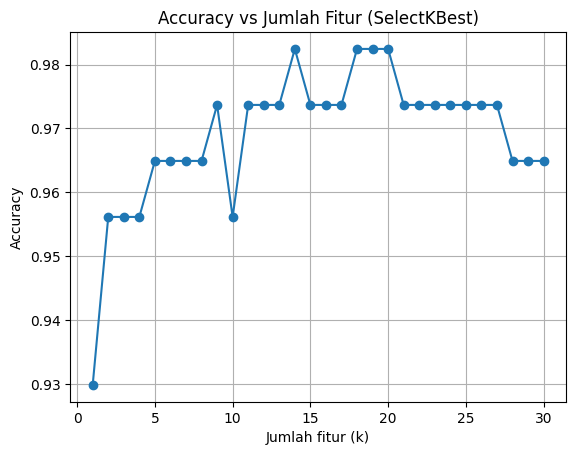

In [11]:
import matplotlib.pyplot as plt

plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.xlabel("Jumlah fitur (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Jumlah Fitur (SelectKBest)")
plt.grid(True)
plt.show()

In [12]:
best_k = int(results_df.loc[results_df["accuracy"].idxmax(), "k"])
best_acc = results_df["accuracy"].max()
print(f"k optimal = {best_k}, dengan accuracy = {best_acc:.4f}")

k optimal = 14, dengan accuracy = 0.9825


In [13]:
best_pipe = Pipeline([
    ("prep", preprocess),
    ("sel", SelectKBest(score_func=f_classif, k=best_k)),
    ("clf", LogisticRegression(max_iter=1000))
])
best_pipe.fit(X_train, y_train)
pred_best = best_pipe.predict(X_test)

print(f"=== Filter (ANOVA) + LR, k={best_k} (optimal) ===")
print("Accuracy:", accuracy_score(y_test, pred_best))
print(classification_report(y_test, pred_best))

=== Filter (ANOVA) + LR, k=14 (optimal) ===
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [14]:
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
mask = best_pipe.named_steps["sel"].get_support()
scores = best_pipe.named_steps["sel"].scores_[mask]

selected = sorted(zip(feat_names[mask], scores), key=lambda t: t[1], reverse=True)
print(f"{best_k} fitur optimal terpilih:")
for name, score in selected:
    print(f"- {name}: {score:.2f}")

14 fitur optimal terpilih:
- num__concave points_worst: 733.72
- num__perimeter_worst: 717.25
- num__radius_worst: 692.86
- num__concave points_mean: 684.53
- num__perimeter_mean: 548.41
- num__area_worst: 522.19
- num__radius_mean: 511.27
- num__area_mean: 444.86
- num__concavity_mean: 397.59
- num__concavity_worst: 319.51
- num__compactness_mean: 263.56
- num__compactness_worst: 238.20
- num__radius_se: 205.43
- num__perimeter_se: 193.17
